In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf 
from tensorflow import keras
import cv2
import os


In [43]:
# Loading the datasets
categories = ['Cardboard', 'Food Organics' ,'Glass' , 'Metal', 'Miscellaneous Trash', 'Paper' , 'Plastic' ,'Textile Trash']
labels = {cat : index for index , cat in enumerate(categories)}

images_per_category=[[],[],[],[],[],[],[],[]]
images_per_category_label=[[],[],[],[],[],[],[],[]]

for index , cat in enumerate(categories):
    basefolder ="RealWaste/"
    sub_directory = os.path.join(basefolder,cat)
    sub_list = os.listdir(sub_directory)

    for image_path in sub_list:
        full_image_path =os.path.join(sub_directory,image_path)
        image_array = cv2.imread(full_image_path)
        images_per_category[index].append(image_array)
        images_per_category_label[index].append(index)



In [47]:
len(images_per_category[0])
len(images_per_category_label[0])

461

Merging the list

In [85]:
all_image=[]
all_image_label=[]
for image_set , label_set in zip(images_per_category,images_per_category_label):
    for per_image , per_label in zip(image_set,label_set):
        all_image.append(per_image)
        all_image_label.append(per_label)

print('Total Number of images : ' , len(all_image))


Total Number of images :  4316


Preprocessing the images --> Resizing

In [88]:
len(all_image[0])

524

In [90]:
target_width = 224
target_height = 224

for index , image in enumerate(all_image):
    all_image[index] = cv2.resize(image ,(target_height,target_width),interpolation=cv2.INTER_AREA)


In [91]:
len(all_image[0])

224

Converting the color of image from BGR ---> RGB

In [92]:
for index , image in enumerate(all_image):
    all_image[index] = cv2.cvtColor(image , cv2.COLOR_BGR2RGB)

Reducing the Noise in Image

In [104]:
guassian_sample=[]
median_blur=[]
bilateral_filter=[]
for index , image in enumerate(all_image):
    #guassian_sample.append(cv2.GaussianBlur(image, ksize=(5,5), sigmaX=0))
    #median_blur.append(cv2.medianBlur(image,ksize=5))
    bilateral_filter.append(cv2.bilateralFilter(image ,d=9 , sigmaColor= 75,sigmaSpace=75))

Visualizing the Images

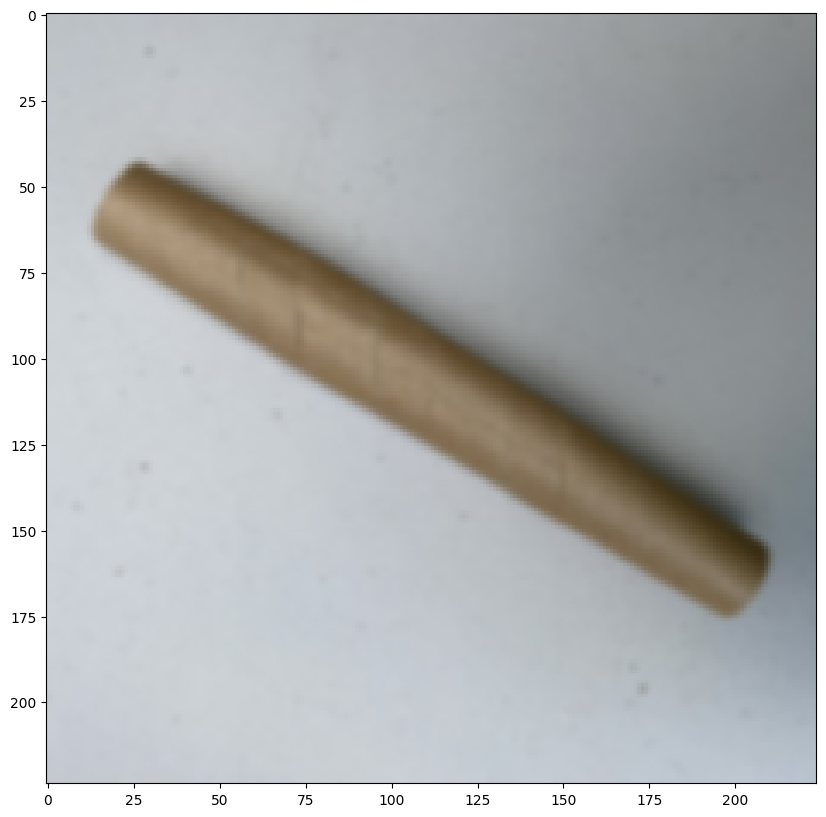

In [100]:
#Guassian blur
plt.figure(figsize=(10,10))
plt.imshow(a[0])

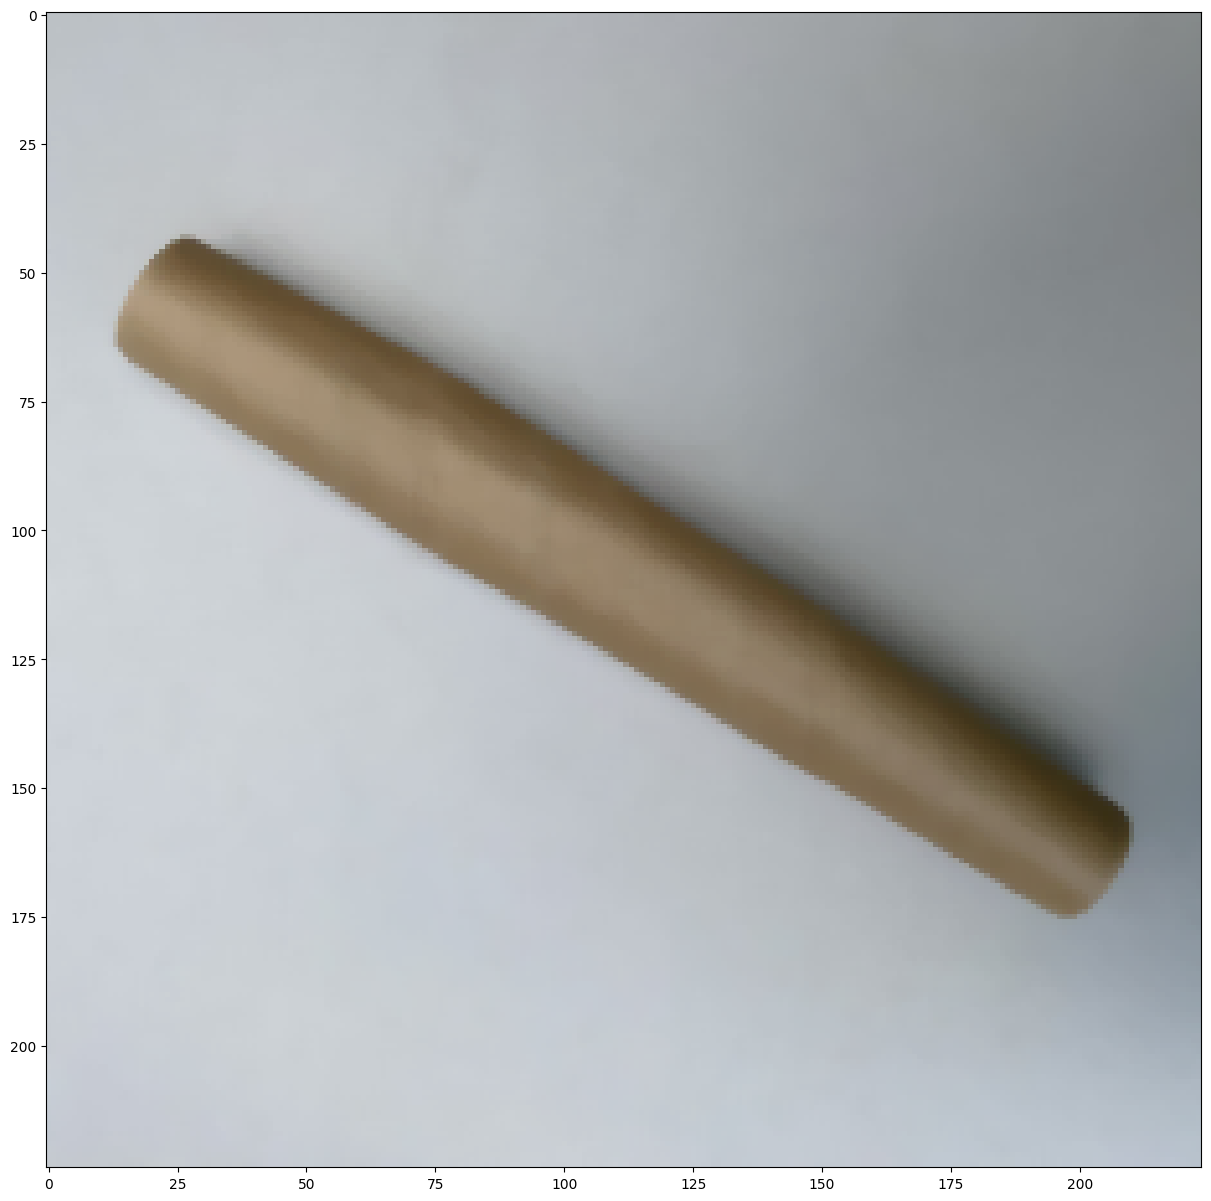

In [107]:
#median blur
plt.figure(figsize=(15,15))
plt.imshow(a[0])

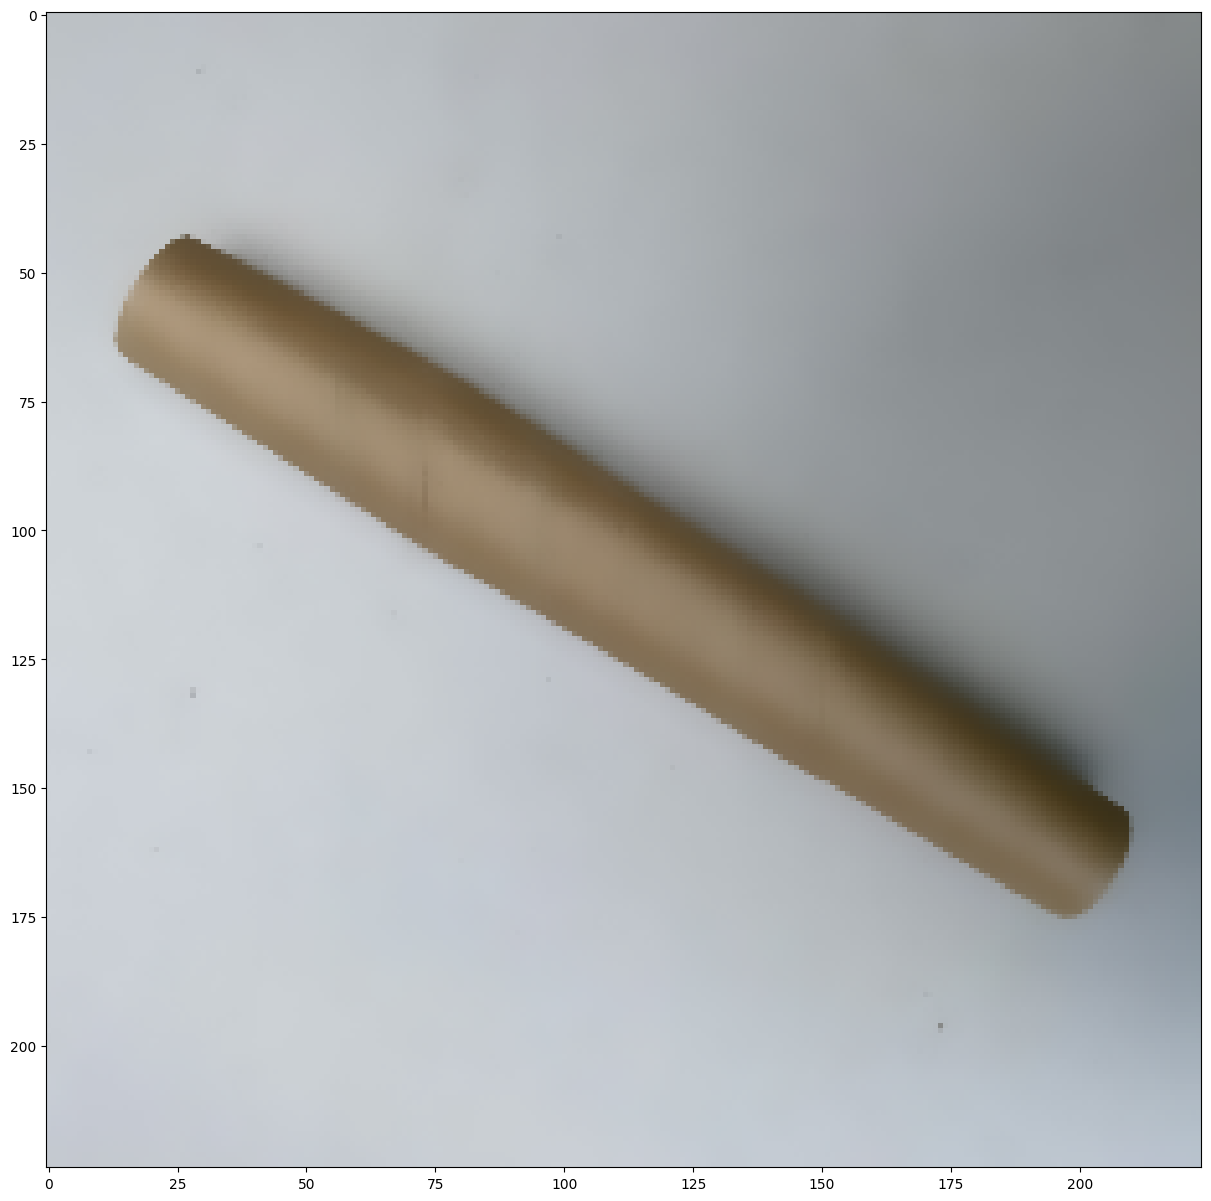

In [106]:
#Bilateral filter
plt.figure(figsize=(15,15))
plt.imshow(bilateral_filter[0])

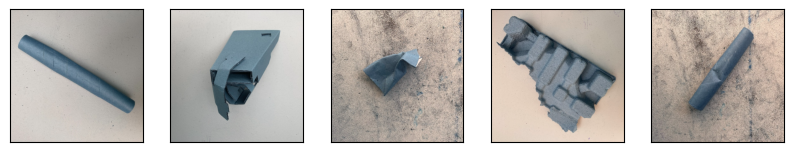

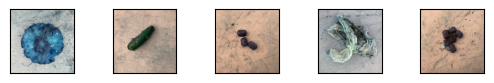

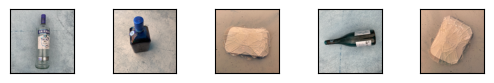

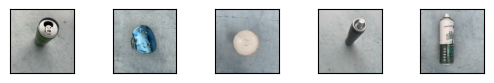

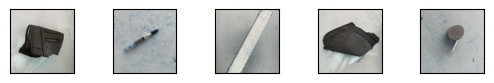

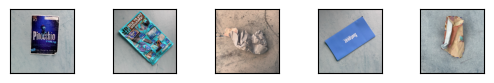

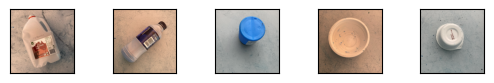

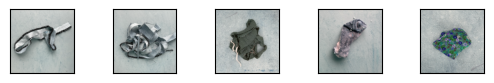

In [93]:
plt.figure(figsize=(10,10))
for y in range(len(categories)):
    for i in range(5):
        plt.subplot(5,5,i+1)
        plt.imshow(images_per_category[y][i])
        plt.xticks([])
        plt.yticks([])
       
    plt.show()